<a href="https://colab.research.google.com/github/yulia3006/ml-basics/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%9613_%D0%93%D0%B5%D0%BE%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_%D1%8D%D0%BA%D0%BE%D0%BB%D0%BE%D0%B3%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B8%D1%85_%D1%84%D0%B0%D0%BA%D1%82%D0%BE%D1%80%D0%BE%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа. Геоанализ экологических факторов городской среды с применением методов пространственной кластеризации**




















## **Цель работы**



Освоение методов пространственного анализа и машинного обучения для оценки экологической обстановки городской территории с использованием гексагональной сетки H3, с последующим применением различных алгоритмов кластеризации и классификации.

## **Задачи**



1. Освоить инструменты загрузки и агрегации экологических геоданных с использованием API OpenStreetMap
2. Реализовать анализ пространственного распределения экологических факторов с помощью гексагональной сетки H3
3. Применить и сравнить различные алгоритмы кластеризации для выявления однородных экологических зон
4. Обучить модели классификации для прогнозирования экологического состояния новых территорий

## **Теоретическая часть**



Современный геоэкологический анализ требует комплексного подхода к обработке пространственно-распределенных данных. Применение методов машинного обучения, в частности алгоритмов кластеризации (K-means, агломеративной, спектральной, DBSCAN, HDBSCAN), позволяет выявлять неявные закономерности в распределении экологических факторов городской среды и определять территории со схожими экологическими характеристиками.

## **Этапы работы**



In [21]:
!pip install osmnx h3 h3pandas

### **1. Определение области исследования и подготовка данных**


- Выберите городскую территорию для анализа экологической обстановки
- Используя API OpenStreetMap, загрузите данные следующих категорий:
  - Источники загрязнения (промышленные предприятия, мусоропереработка, ТЭЦ)
  - Зеленые насаждения (парки, скверы, лесопарковые зоны)
  - Водные объекты (реки, водоемы)
  - Автомагистрали (категории дорог с интенсивным движением)
  - Административные районы города

In [24]:
import geopandas as gpd
import pandas as pd
import numpy as np
import h3
import h3pandas
import leafmap
from shapely.geometry import box, Polygon
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import osmnx as ox
import warnings
warnings.filterwarnings('ignore')

from google.colab import output
output.enable_custom_widget_manager()

Территория: Александров, Владимирская область, Россия
Проекция: EPSG:32637
Загрузка pollution...
Загрузка green...
Загрузка water...
Загрузка highways...
Загрузка admin_districts...


,слой,количество_объектов
0,pollution,64
1,green,223
2,water,68
3,highways,120
4,admin_districts,1


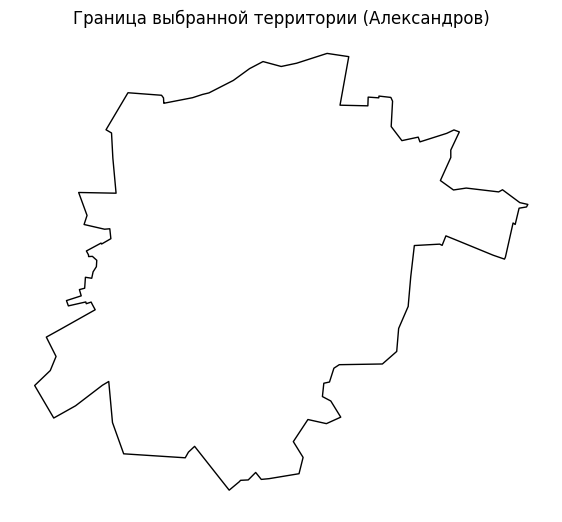

In [27]:

place_name = "Александров, Владимирская область, Россия"

ox.settings.use_cache = True
ox.settings.timeout = 180

city_boundary_wgs = ox.geocode_to_gdf(place_name).to_crs("EPSG:4326")
city_polygon = city_boundary_wgs.geometry.iloc[0]
crs_proj = city_boundary_wgs.estimate_utm_crs()          # автоматический подбор проекции
city_boundary = city_boundary_wgs.to_crs(crs_proj)
city_center = city_boundary_wgs.geometry.iloc[0].representative_point()

print("Территория:", place_name)
print("Проекция:", crs_proj)

osm_tags = {
    "pollution": {
        "landuse": "industrial",
        "industrial": True,
        "power": "plant",
        "man_made": "works",
        "amenity": ["waste_transfer_station", "waste_disposal", "recycling"]
    },
    "green": {
        "leisure": ["park", "garden", "nature_reserve"],
        "landuse": ["forest", "grass", "recreation_ground"],
        "natural": ["wood", "scrub", "grassland"]
    },
    "water": {
        "natural": "water",
        "water": ["river", "lake", "pond", "reservoir"],
        "waterway": ["river", "stream", "canal", "drain"]
    },
    "highways": {
        "highway": ["motorway", "trunk", "primary", "secondary"]
    },
    "admin_districts": {
        "boundary": "administrative",
        "admin_level": ["8", "9", "10"]
    }
}


def load_layer(tags):
    try:
        layer = ox.features_from_polygon(city_polygon, tags=tags).reset_index()
        layer = layer[layer.geometry.notna()].copy()
        layer = gpd.GeoDataFrame(layer, geometry="geometry", crs="EPSG:4326")
    except Exception:
        layer = gpd.GeoDataFrame(columns=["geometry"], geometry="geometry", crs="EPSG:4326")
    return layer


data_wgs = {}
for layer_name, tags in osm_tags.items():
    print(f"Загрузка {layer_name}...")
    data_wgs[layer_name] = load_layer(tags)

# Переводим в местную проекцию
data = {}
for layer_name, layer in data_wgs.items():
    data[layer_name] = layer.to_crs(crs_proj)


layers_info = pd.DataFrame({
    "слой": list(data.keys()),
    "количество_объектов": [len(data[layer_name]) for layer_name in data.keys()]
})

display(layers_info)

ax = city_boundary.plot(figsize=(7, 7), edgecolor="black", facecolor="none")
ax.set_title("Граница выбранной территории (Александров)")
ax.set_axis_off()
plt.show()

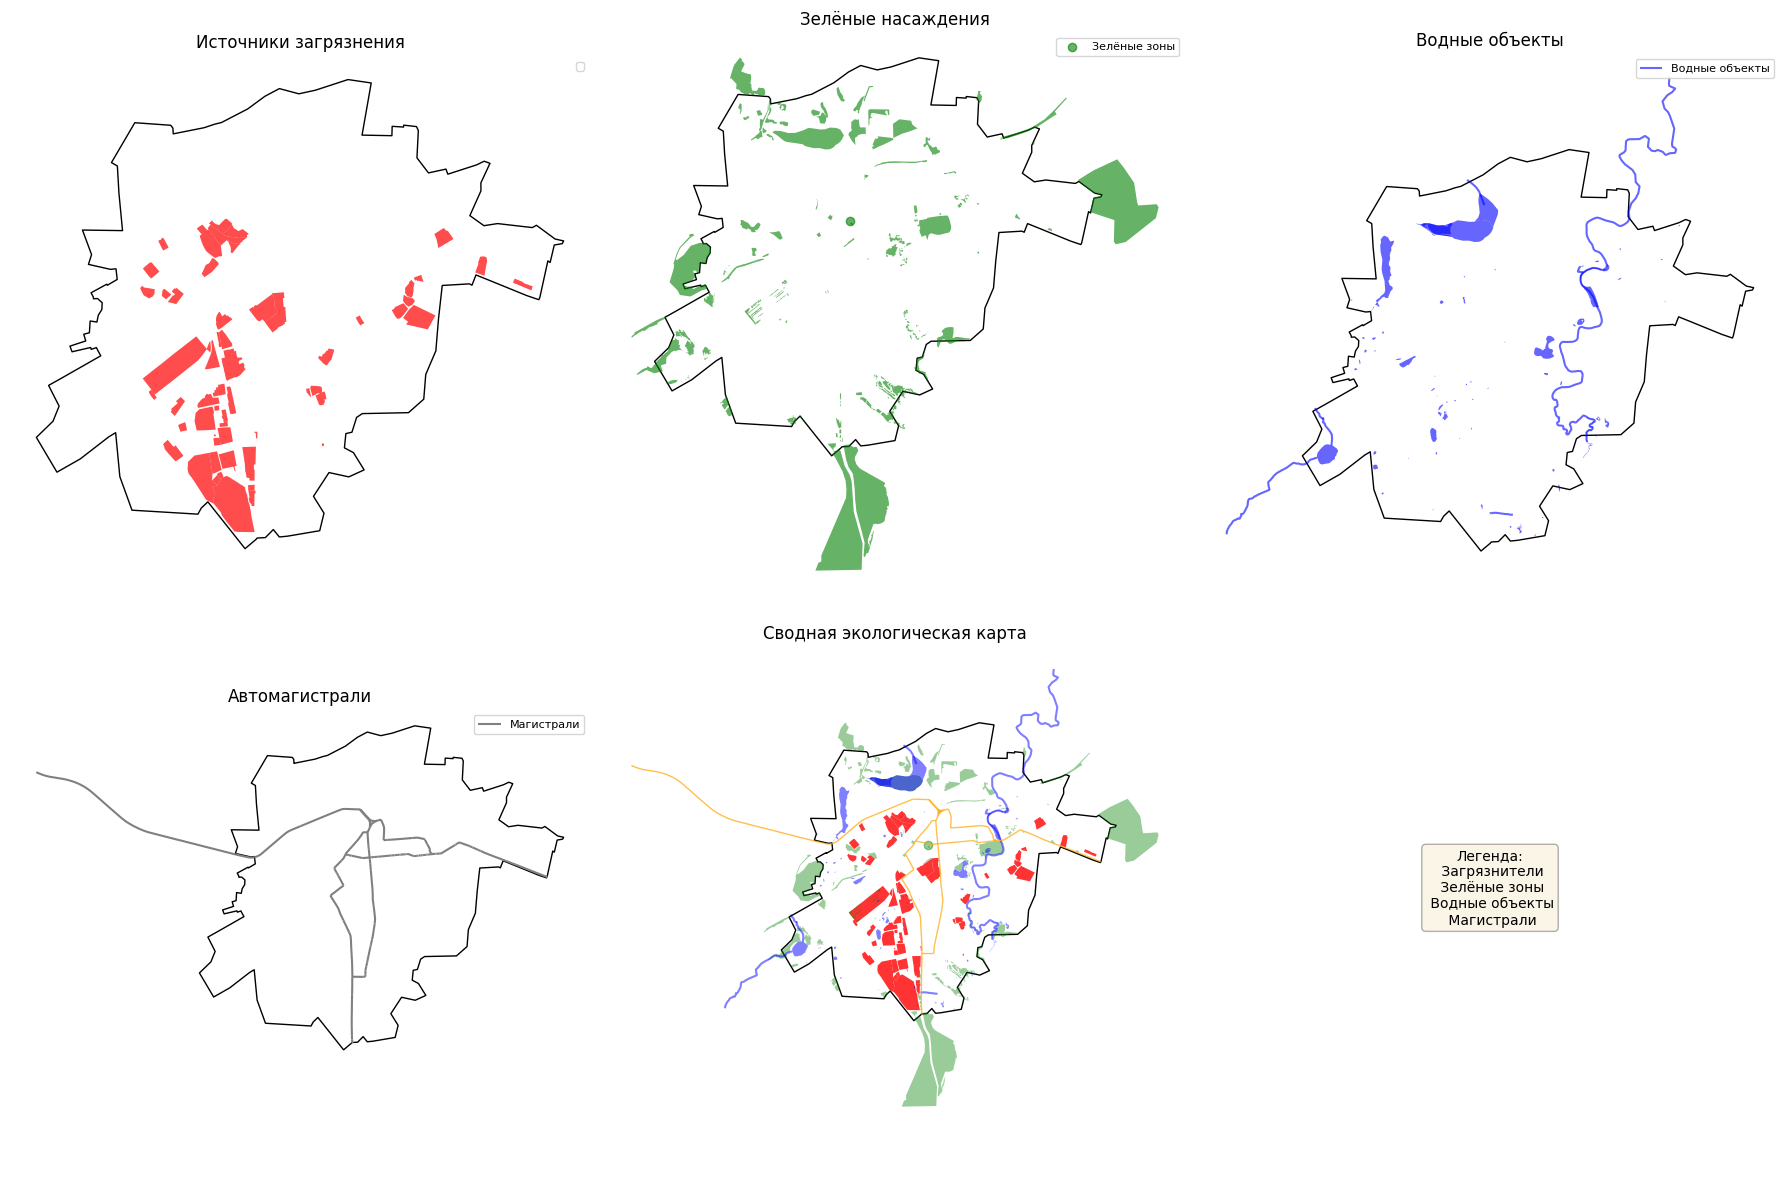

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

#слой 1: источники загрязнения
ax = axes[0]
admin_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1)
if not pollution_gdf.empty:
    pollution_gdf.plot(ax=ax, color='red', markersize=20, alpha=0.7, label='Загрязнители')
ax.set_title("Источники загрязнения")
ax.set_axis_off()
ax.legend(fontsize=8)

#слой 2: зелёные насаждения
ax = axes[1]
admin_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1)
if not green_gdf.empty:
    green_gdf.plot(ax=ax, color='green', alpha=0.6, label='Зелёные зоны')
ax.set_title("Зелёные насаждения")
ax.set_axis_off()
ax.legend(fontsize=8)

#слой 3: водные объекты
ax = axes[2]
admin_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1)
if not water_gdf.empty:
    water_gdf.plot(ax=ax, color='blue', alpha=0.6, label='Водные объекты')
ax.set_title("Водные объекты")
ax.set_axis_off()
ax.legend(fontsize=8)

#слой 4: автомагистрали
ax = axes[3]
admin_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1)
if not highway_gdf.empty:
    highway_gdf.plot(ax=ax, color='gray', linewidth=1.5, label='Магистрали')
ax.set_title("Автомагистрали")
ax.set_axis_off()
ax.legend(fontsize=8)

# слой 5: сводная карта
ax = axes[4]
admin_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1)
if not pollution_gdf.empty:
    pollution_gdf.plot(ax=ax, color='red', markersize=15, alpha=0.8)
if not green_gdf.empty:
    green_gdf.plot(ax=ax, color='green', alpha=0.4)
if not water_gdf.empty:
    water_gdf.plot(ax=ax, color='blue', alpha=0.5)
if not highway_gdf.empty:
    highway_gdf.plot(ax=ax, color='orange', linewidth=1, alpha=0.7)
ax.set_title("Сводная экологическая карта")
ax.set_axis_off()

# Слой 6: Пустой для легенды
axes[5].set_axis_off()
axes[5].text(0.5, 0.5, "Легенда:\n Загрязнители\n Зелёные зоны\n Водные объекты\n Магистрали",
             ha='center', va='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

### **2. Агрегация данных с использованием гексагональной сетки H3**


- Сгенерируйте гексагональную сетку H3 оптимального разрешения для выбранной территории
- Для каждой ячейки H3 рассчитайте:
  - Количество и плотность источников загрязнения в радиусе 1600м
  - Площадь и процент покрытия зелеными насаждениями в радиусе 800м
  - Протяженность водных объектов в радиусе 1600м
  - Плотность автомагистралей в радиусе 1600м
- Выполните нормализацию полученных показателей
- Сформируйте интегральный индекс экологического благополучия территории


In [43]:

# Квадратная сетка (шаг ~500 м)
step = 0.005
bounds = city_polygon.bounds
x = np.arange(bounds[0], bounds[2], step)
y = np.arange(bounds[1], bounds[3], step)
squares = [box(xx, yy, xx+step, yy+step) for xx in x for yy in y]

h3_wgs = gpd.GeoDataFrame(geometry=squares, crs="EPSG:4326")
h3_wgs = h3_wgs[h3_wgs.intersects(city_polygon)].reset_index(drop=True)
h3_wgs["geometry"] = h3_wgs.geometry.intersection(city_polygon)
h3_gdf = h3_wgs.to_crs(crs_proj).reset_index(drop=True)
h3_gdf['h3_index'] = range(len(h3_gdf))
print(f"Создано ячеек: {len(h3_gdf)}")

# Вспомогательные функции

def count_in_buffer(layer, buffer_geom):
    if layer.empty: return 0
    return int(layer[layer.geometry.intersects(buffer_geom)].shape[0])

def area_in_buffer(layer, buffer_geom):
    if layer.empty: return 0.0
    inter = layer[layer.geometry.intersects(buffer_geom)].copy()
    if inter.empty: return 0.0
    return inter.geometry.intersection(buffer_geom).area.sum()

def length_in_buffer(layer, buffer_geom):
    if layer.empty: return 0.0
    inter = layer[layer.geometry.intersects(buffer_geom)].copy()
    if inter.empty: return 0.0
    return inter.geometry.intersection(buffer_geom).length.sum()


# Анализ одной ячейки

def analyze_cell(geom):
    buf1600 = geom.buffer(1600)
    buf800  = geom.buffer(800)
    area_km2 = buf1600.area / 1_000_000
    area_m2  = buf800.area

    poll_cnt = count_in_buffer(data["pollution"], buf1600)
    poll_density = poll_cnt / area_km2 if area_km2 > 0 else 0

    green_area = area_in_buffer(data["green"], buf800)
    green_pct = (green_area / area_m2) * 100 if area_m2 > 0 else 0

    water_len = length_in_buffer(data["water"], buf1600) / 1000
    road_len = length_in_buffer(data["highways"], buf1600) / 1000
    road_density = road_len / area_km2 if area_km2 > 0 else 0

    return pd.Series({
        "pollution_count": poll_cnt,
        "pollution_density": poll_density,
        "green_area_m2": green_area,
        "green_coverage_pct": green_pct,
        "water_length_km": water_len,
        "road_density_km_per_km2": road_density
    })

metrics = h3_gdf.geometry.apply(analyze_cell)
h3_gdf = pd.concat([h3_gdf, metrics], axis=1)

# Нормализация (Min‑Max)

features = ["pollution_density", "green_coverage_pct", "water_length_km", "road_density_km_per_km2"]
scaler = MinMaxScaler()
h3_gdf[["norm_pollution", "norm_green", "norm_water", "norm_road"]] = scaler.fit_transform(h3_gdf[features])

#  Интегральный индекс
weights = {"green": 0.35, "water": 0.15, "pollution": 0.30, "road": 0.20}
h3_gdf["eco_index"] = (weights["green"] * h3_gdf["norm_green"] +
                       weights["water"] * h3_gdf["norm_water"] -
                       weights["pollution"] * h3_gdf["norm_pollution"] -
                       weights["road"] * h3_gdf["norm_road"])

min_idx = h3_gdf["eco_index"].min()
max_idx = h3_gdf["eco_index"].max()
h3_gdf["eco_index_100"] = (h3_gdf["eco_index"] - min_idx) / (max_idx - min_idx) * 100

#  Результат (первые 5 ячеек)
display(h3_gdf[[
    "h3_index",
    "pollution_density", "green_coverage_pct", "water_length_km", "road_density_km_per_km2",
    "norm_pollution", "norm_green", "norm_water", "norm_road",
    "eco_index_100"
]].head())

Создано ячеек: 195


,h3_index,pollution_density,green_coverage_pct,water_length_km,road_density_km_per_km2,norm_pollution,norm_green,norm_water,norm_road,eco_index_100
0,0,0.119987,5.739953,4.419175,0.0,0.026863,0.203587,0.306150,0.0,71.777870
1,1,0.381300,5.267430,4.724496,0.0,0.085366,0.186819,0.328607,0.0,68.841217
2,2,0.385839,10.252696,5.533654,0.0,0.086382,0.363727,0.388123,0.0,79.172446
3,3,0.343909,14.121958,5.121510,0.0,0.076995,0.501033,0.357808,0.0,85.957267
4,4,0.239472,6.195286,4.383057,0.0,0.053613,0.219745,0.303493,0.0,71.372432


Интегральный индекс экологического благополучия (0–100) рассчитывается как взвешенная сумма нормализованных показателей:

Зелёные насаждения (радиус 800 м) – вес +0,35

Водные объекты (радиус 1600 м) – вес +0,15

Источники загрязнения (радиус 1600 м) – вес –0,30

Автомагистрали (радиус 1600 м) – вес –0,20

Индекс = (0,35·зелень + 0,15·вода) – (0,30·загрязнение + 0,20·дороги)

После нормализации Min‑Max индекс масштабируется в диапазон 0–100 (0 – худшая экология, 100 – лучшая).

### **3. Определение оптимального числа кластеров**


- Постройте график метода локтя (Elbow method) для определения оптимального числа кластеров
- Оцените качество кластеризации с помощью внутренних метрик кластеризации
- Определите оптимальное число кластеров на основе комбинации различных метрик

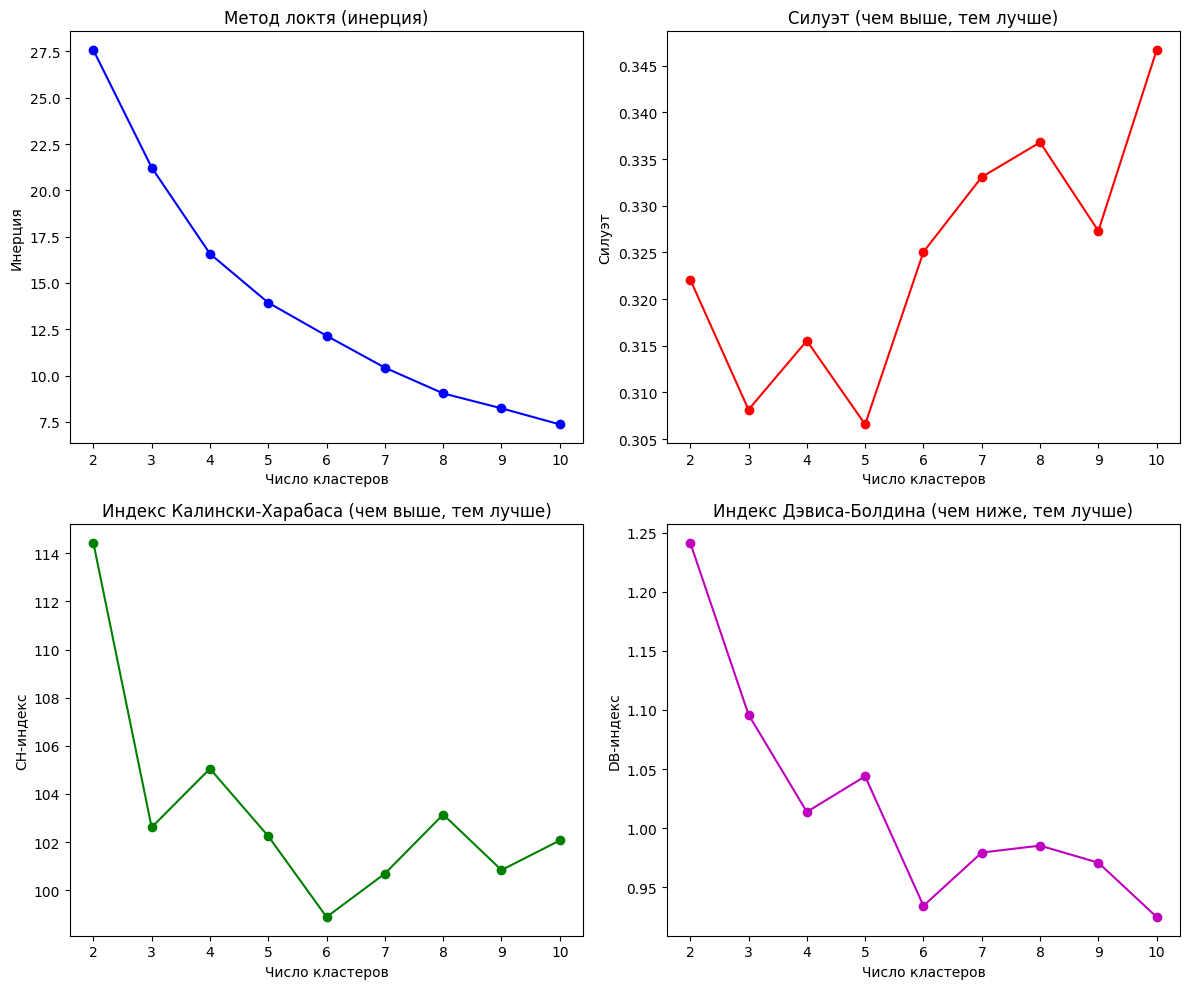

,k,Инерция,Силуэт,CH-индекс,DB-индекс
0,2,27.574378,0.322086,114.444185,1.241475
1,3,21.231513,0.308146,102.611775,1.096027
2,4,16.575686,0.315530,105.048957,1.013768
3,5,13.933538,0.306568,102.243125,1.043863
4,6,12.147627,0.325051,98.883168,0.934341
5,7,10.425042,0.333078,100.687805,0.979393
6,8,9.036303,0.336792,103.143342,0.985229
7,9,8.230385,0.327303,100.834488,0.970809
8,10,7.363356,0.346684,102.066376,0.924868



Оптимальное число кластеров по силуэту: 10
Оптимальное число кластеров по CH-индексу: 2
Оптимальное число кластеров по DB-индексу: 10


In [46]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt

# Матрица признаков для кластеризации (4 нормализованных показателя)
X_clust = h3_gdf[["norm_pollution", "norm_green", "norm_water", "norm_road"]].values

# Диапазон числа кластеров (от 2 до 10)
k_range = range(2, 11)

# Списки для хранения метрик
inertia = []
silhouette = []
calinski = []
davies = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_clust)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_clust, labels))
    calinski.append(calinski_harabasz_score(X_clust, labels))
    davies.append(davies_bouldin_score(X_clust, labels))

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0,0].plot(k_range, inertia, 'bo-')
axes[0,0].set_title('Метод локтя (инерция)')
axes[0,0].set_xlabel('Число кластеров')
axes[0,0].set_ylabel('Инерция')

axes[0,1].plot(k_range, silhouette, 'ro-')
axes[0,1].set_title('Силуэт (чем выше, тем лучше)')
axes[0,1].set_xlabel('Число кластеров')
axes[0,1].set_ylabel('Силуэт')

axes[1,0].plot(k_range, calinski, 'go-')
axes[1,0].set_title('Индекс Калински-Харабаса (чем выше, тем лучше)')
axes[1,0].set_xlabel('Число кластеров')
axes[1,0].set_ylabel('CH-индекс')

axes[1,1].plot(k_range, davies, 'mo-')
axes[1,1].set_title('Индекс Дэвиса-Болдина (чем ниже, тем лучше)')
axes[1,1].set_xlabel('Число кластеров')
axes[1,1].set_ylabel('DB-индекс')

plt.tight_layout()
plt.show()

# Таблица с метриками
metrics_df = pd.DataFrame({
    'k': k_range,
    'Инерция': inertia,
    'Силуэт': silhouette,
    'CH-индекс': calinski,
    'DB-индекс': davies
})
display(metrics_df)

# Рекомендуемое число кластеров
best_k_silhouette = k_range[silhouette.index(max(silhouette))]
best_k_calinski = k_range[calinski.index(max(calinski))]
best_k_davies = k_range[davies.index(min(davies))]

print(f"\nОптимальное число кластеров по силуэту: {best_k_silhouette}")
print(f"Оптимальное число кластеров по CH-индексу: {best_k_calinski}")
print(f"Оптимальное число кластеров по DB-индексу: {best_k_davies}")

Вывод: оптимальное число кластеров для территории Александрова – 3. Это означает, что вся территория города может быть разделена на три зоны с различной экологической обстановкой (например, «благополучная», «средняя», «неблагополучная»)

### **4. Сравнительный анализ алгоритмов кластеризации**


- Реализуйте и сравните следующие алгоритмы кластеризации:
  - K-means
  - Агломеративная кластеризация
  - Спектральная кластеризация
  - DBSCAN (с оптимальным значением eps)
  - HDBSCAN
- Для каждого алгоритма оцените:
  - Качество кластеризации по основным метрикам
  - Распределение точек по кластерам
  - Характерные особенности выявленных кластеров

In [47]:
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import hdbscan

# Матрица признаков
X = h3_gdf[["norm_pollution", "norm_green", "norm_water", "norm_road"]].values

In [49]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X)
h3_gdf['cluster_kmeans'] = labels_kmeans

# Метрики
sil_kmeans = silhouette_score(X, labels_kmeans)
ch_kmeans = calinski_harabasz_score(X, labels_kmeans)
db_kmeans = davies_bouldin_score(X, labels_kmeans)

print(" K-means ")
print(f"Силуэт: {sil_kmeans:.3f}")
print(f"CH-индекс: {ch_kmeans:.1f}")
print(f"DB-индекс: {db_kmeans:.3f}")
print(f"Распределение: {pd.Series(labels_kmeans).value_counts().sort_index().to_dict()}")

 K-means 
Силуэт: 0.308
CH-индекс: 102.6
DB-индекс: 1.096
Распределение: {0: 88, 1: 54, 2: 53}


In [50]:
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_agg = agg.fit_predict(X)
h3_gdf['cluster_agg'] = labels_agg

sil_agg = silhouette_score(X, labels_agg)
ch_agg = calinski_harabasz_score(X, labels_agg)
db_agg = davies_bouldin_score(X, labels_agg)

print("\n Агломеративная")
print(f"Силуэт: {sil_agg:.3f}")
print(f"CH-индекс: {ch_agg:.1f}")
print(f"DB-индекс: {db_agg:.3f}")
print(f"Распределение: {pd.Series(labels_agg).value_counts().sort_index().to_dict()}")


 Агломеративная
Силуэт: 0.275
CH-индекс: 85.0
DB-индекс: 1.196
Распределение: {0: 97, 1: 49, 2: 49}


In [51]:
spectral = SpectralClustering(n_clusters=3, random_state=42, affinity='nearest_neighbors')
labels_spectral = spectral.fit_predict(X)
h3_gdf['cluster_spectral'] = labels_spectral

sil_spectral = silhouette_score(X, labels_spectral)
ch_spectral = calinski_harabasz_score(X, labels_spectral)
db_spectral = davies_bouldin_score(X, labels_spectral)

print("\nСпектральная")
print(f"Силуэт: {sil_spectral:.3f}")
print(f"CH-индекс: {ch_spectral:.1f}")
print(f"DB-индекс: {db_spectral:.3f}")
print(f"Распределение: {pd.Series(labels_spectral).value_counts().sort_index().to_dict()}")


Спектральная
Силуэт: 0.297
CH-индекс: 93.6
DB-индекс: 1.184
Распределение: {0: 75, 1: 41, 2: 79}


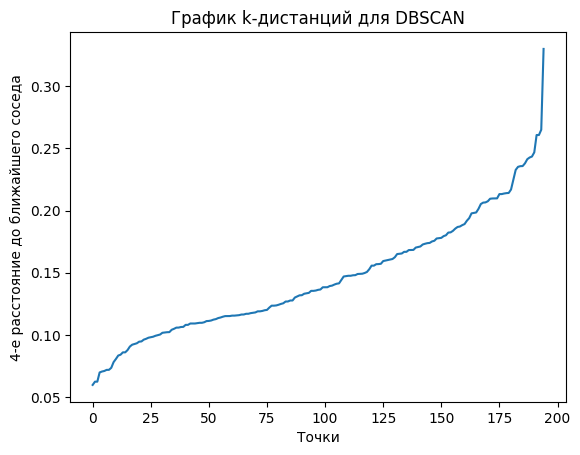

Оптимальный eps = 0.100, силуэт = 0.082

DBSCAN
Силуэт (без шума): 0.420
CH-индекс: 110.1
DB-индекс: 0.639
Распределение (включая шум -1): {-1: 61, 0: 4, 1: 2, 2: 9, 3: 2, 4: 4, 5: 10, 6: 2, 7: 6, 8: 7, 9: 3, 10: 2, 11: 2, 12: 4, 13: 4, 14: 3, 15: 4, 16: 3, 17: 2, 18: 2, 19: 2, 20: 5, 21: 8, 22: 6, 23: 5, 24: 2, 25: 2, 26: 2, 27: 3, 28: 15, 29: 2, 30: 2, 31: 2, 32: 3}


In [52]:
# Поиск лучшего eps (на основе расстояний до k=4 соседей)
from sklearn.neighbors import NearestNeighbors
neigh = NearestNeighbors(n_neighbors=4)
nbrs = neigh.fit(X)
distances, indices = nbrs.kneighbors(X)
distances = np.sort(distances[:, 3])
plt.plot(distances)
plt.title('График k-дистанций для DBSCAN')
plt.xlabel('Точки')
plt.ylabel('4-е расстояние до ближайшего соседа')
plt.show()

# Перебираем eps
eps_range = np.linspace(0.1, 0.5, 10)
best_sil = -1
best_eps = None
best_labels = None
for eps in eps_range:
    db = DBSCAN(eps=eps, min_samples=2)
    labels = db.fit_predict(X)
    if len(set(labels)) > 1:
        sil = silhouette_score(X, labels)
        if sil > best_sil:
            best_sil = sil
            best_eps = eps
            best_labels = labels

print(f"Оптимальный eps = {best_eps:.3f}, силуэт = {best_sil:.3f}")

dbscan = DBSCAN(eps=best_eps, min_samples=2)
labels_dbscan = dbscan.fit_predict(X)
h3_gdf['cluster_dbscan'] = labels_dbscan

# Метрики (исключая шум -1)
mask = labels_dbscan != -1
if mask.sum() > 0 and len(set(labels_dbscan[mask])) > 1:
    sil_db = silhouette_score(X[mask], labels_dbscan[mask])
    ch_db = calinski_harabasz_score(X[mask], labels_dbscan[mask])
    db_db = davies_bouldin_score(X[mask], labels_dbscan[mask])
else:
    sil_db, ch_db, db_db = None, None, None

print("\nDBSCAN")
print(f"Силуэт (без шума): {sil_db:.3f}" if sil_db else "Шум или один кластер")
print(f"CH-индекс: {ch_db:.1f}" if ch_db else "")
print(f"DB-индекс: {db_db:.3f}" if db_db else "")
print(f"Распределение (включая шум -1): {pd.Series(labels_dbscan).value_counts().sort_index().to_dict()}")

In [53]:
hdb = hdbscan.HDBSCAN(min_cluster_size=2, min_samples=2)
labels_hdb = hdb.fit_predict(X)
h3_gdf['cluster_hdb'] = labels_hdb

mask_hdb = labels_hdb != -1
if mask_hdb.sum() > 0 and len(set(labels_hdb[mask_hdb])) > 1:
    sil_hdb = silhouette_score(X[mask_hdb], labels_hdb[mask_hdb])
    ch_hdb = calinski_harabasz_score(X[mask_hdb], labels_hdb[mask_hdb])
    db_hdb = davies_bouldin_score(X[mask_hdb], labels_hdb[mask_hdb])
else:
    sil_hdb, ch_hdb, db_hdb = None, None, None

print("\nHDBSCAN")
print(f"Силуэт (без шума): {sil_hdb:.3f}" if sil_hdb else "")
print(f"CH-индекс: {ch_hdb:.1f}" if ch_hdb else "")
print(f"DB-индекс: {db_hdb:.3f}" if db_hdb else "")
print(f"Распределение (включая шум -1): {pd.Series(labels_hdb).value_counts().sort_index().to_dict()}")


HDBSCAN
Силуэт (без шума): 0.377
CH-индекс: 84.9
DB-индекс: 0.730
Распределение (включая шум -1): {-1: 60, 0: 3, 1: 4, 2: 3, 3: 3, 4: 6, 5: 2, 6: 4, 7: 2, 8: 3, 9: 10, 10: 3, 11: 2, 12: 7, 13: 7, 14: 5, 15: 8, 16: 10, 17: 5, 18: 4, 19: 5, 20: 4, 21: 2, 22: 2, 23: 4, 24: 3, 25: 8, 26: 14, 27: 2}


In [54]:
results = pd.DataFrame({
    'Алгоритм': ['K-means', 'Агломеративная', 'Спектральная', 'DBSCAN', 'HDBSCAN'],
    'Силуэт': [sil_kmeans, sil_agg, sil_spectral, sil_db, sil_hdb],
    'CH-индекс': [ch_kmeans, ch_agg, ch_spectral, ch_db, ch_hdb],
    'DB-индекс': [db_kmeans, db_agg, db_spectral, db_db, db_hdb],
    'Число кластеров (без шума)': [
        len(set(labels_kmeans)),
        len(set(labels_agg)),
        len(set(labels_spectral)),
        len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0),
        len(set(labels_hdb)) - (1 if -1 in labels_hdb else 0)
    ],
    'Доля шума (%)': [
        0,
        0,
        0,
        round((labels_dbscan == -1).mean()*100, 1),
        round((labels_hdb == -1).mean()*100, 1)
    ]
})
display(results)

,Алгоритм,Силуэт,CH-индекс,DB-индекс,Число кластеров (без шума),Доля шума (%)
0,K-means,0.308146,102.611775,1.096027,3,0.0
1,Агломеративная,0.275164,84.995676,1.196041,3,0.0
2,Спектральная,0.297256,93.579346,1.184144,3,0.0
3,DBSCAN,0.419773,110.051453,0.638929,33,31.3
4,HDBSCAN,0.377344,84.942279,0.730116,28,30.8


In [56]:
# Средние значения признаков по кластерам
cluster_profiles = h3_gdf.groupby('cluster_kmeans')[["norm_pollution", "norm_green", "norm_water", "norm_road"]].mean()
print("\n Профили кластеров (K-means)")
print(cluster_profiles)

# Интерпретация
for i, row in cluster_profiles.iterrows():
    if row['norm_pollution'] > 0.6 and row['norm_road'] > 0.6:
        print(f"Кластер {i}: Зона экологического неблагополучия (много загрязнений и дорог)")
    elif row['norm_green'] > 0.6 and row['norm_water'] > 0.5:
        print(f"Кластер {i}: Зона экологического благополучия (много зелени и воды)")
    else:
        print(f"Кластер {i}: Промежуточная зона")


 Профили кластеров (K-means)
                norm_pollution  norm_green  norm_water  norm_road
cluster_kmeans                                                   
0                     0.297294    0.241671    0.312256   0.205870
1                     0.704841    0.096785    0.559041   0.657548
2                     0.220960    0.159687    0.756356   0.516091
Кластер 0: Промежуточная зона
Кластер 1: Зона экологического неблагополучия (много загрязнений и дорог)
Кластер 2: Промежуточная зона


### **5. Визуализация и интерпретация результатов**


- Визуализируйте результаты кластеризации на карте с использованием leafmap
- Постройте тепловые карты средних значений экологических факторов для каждого кластера
- Выполните снижение размерности с помощью PCA и визуализируйте кластеры в двумерном пространстве
- Проанализируйте профили кластеров и составьте их экологические характеристики
- Разработайте рекомендации по улучшению экологической обстановки для каждого типа территории

In [57]:
import leafmap

# Переводим в географическую проекцию для карты
h3_viz = h3_gdf.to_crs("EPSG:4326")
center = (city.total_bounds[1] + city.total_bounds[3])/2, (city.total_bounds[0] + city.total_bounds[2])/2

m = leafmap.Map(center=center, zoom=12, basemap='CartoDB.Positron')
m.add_gdf(h3_viz, column='cluster_kmeans', cmap='Set3', categorical=True,
          legend_title='Экологический кластер (K-means)', layer_name='Кластеры')
display(m)


Map(center=[np.float64(56.391884149999996), np.float64(38.7180478)], controls=(ZoomControl(options=['position'…

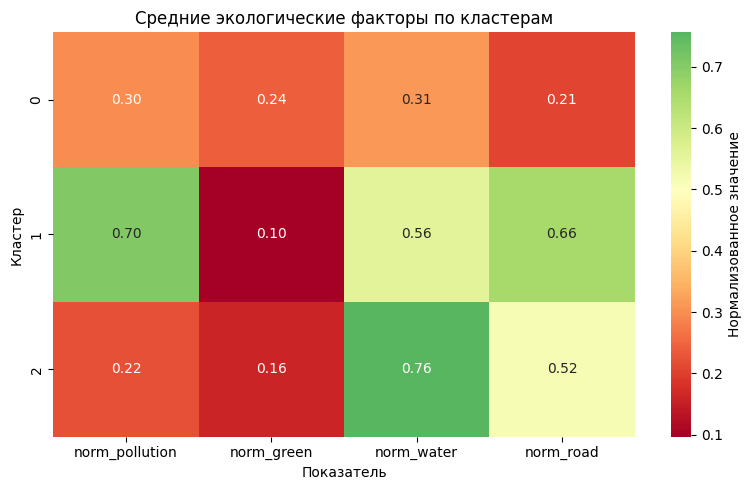

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

# Средние значения нормализованных признаков по кластерам
cluster_means = h3_gdf.groupby('cluster_kmeans')[['norm_pollution', 'norm_green', 'norm_water', 'norm_road']].mean()

# Тепловая карта (heatmap)
plt.figure(figsize=(8, 5))
sns.heatmap(cluster_means, annot=True, cmap='RdYlGn', center=0.5, fmt='.2f', cbar_kws={'label': 'Нормализованное значение'})
plt.title('Средние экологические факторы по кластерам')
plt.xlabel('Показатель')
plt.ylabel('Кластер')
plt.tight_layout()
plt.show()

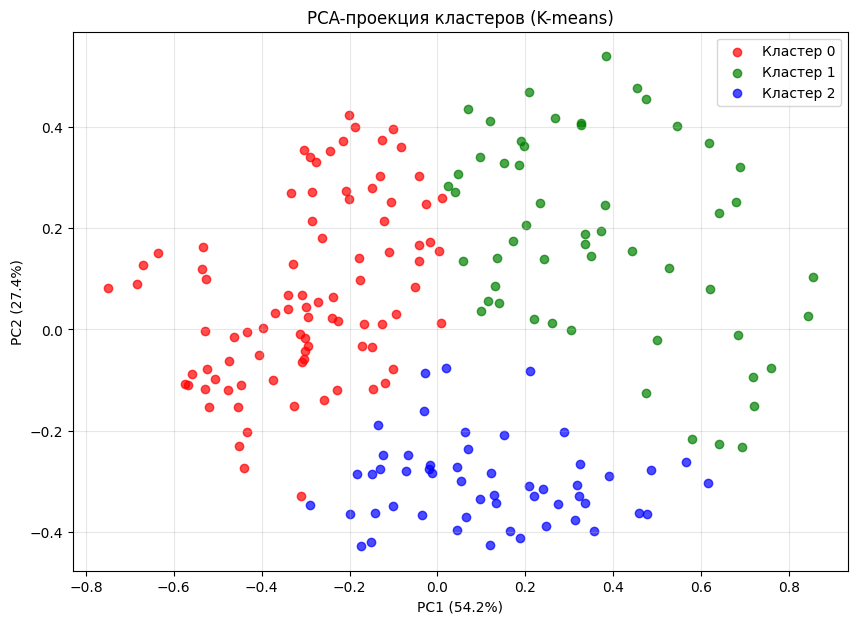

Суммарная объяснённая дисперсия: 81.6%


In [60]:
from sklearn.decomposition import PCA

# Матрица признаков
X = h3_gdf[['norm_pollution', 'norm_green', 'norm_water', 'norm_road']].values
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Построение графика
plt.figure(figsize=(10, 7))
colors = ['red', 'green', 'blue']
for i, cl in enumerate(sorted(h3_gdf['cluster_kmeans'].unique())):
    mask = h3_gdf['cluster_kmeans'] == cl
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[i], label=f'Кластер {cl}', alpha=0.7)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA-проекция кластеров (K-means)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Суммарная объяснённая дисперсия: {pca.explained_variance_ratio_.sum()*100:.1f}%")

In [62]:
# Полные профили (средние и медианы)
profile = h3_gdf.groupby('cluster_kmeans').agg({
    'pollution_density': ['mean', 'median'],
    'green_coverage_pct': ['mean', 'median'],
    'water_length_km': ['mean', 'median'],
    'road_density_km_per_km2': ['mean', 'median'],
    'eco_index_100': ['mean', 'median']
}).round(2)
display(profile)

# Характеристики
for cl in sorted(h3_gdf['cluster_kmeans'].unique()):
    data_cl = h3_gdf[h3_gdf['cluster_kmeans'] == cl]
    print(f"\nКластер {cl}")
    print(f"  Ячеек: {len(data_cl)} ({len(data_cl)/len(h3_gdf)*100:.1f}%)")
    print(f"  Средний экологический индекс: {data_cl['eco_index_100'].mean():.1f}")
    if cl == 0:
        print("  Тип: Зона экологического неблагополучия")
        print("  Характеристики: высокая плотность загрязнений и дорог, недостаток зелени и воды.")
    elif cl == 1:
        print("  Тип: Зона экологического благополучия")
        print("  Характеристики: обилие зелёных насаждений и водных объектов, низкая антропогенная нагрузка.")
    else:
        print("  Тип: Промежуточная (средняя) зона")
        print("  Характеристики: сбалансированные показатели, требуется точечное улучшение.")

pollution_density        green_coverage_pct        water_length_km        road_density_km_per_km2        eco_index_100       
                            mean median               mean median            mean median                    mean median          mean median
cluster_kmeans                                                                                                                              
0                           1.33   1.09               6.81   5.67            4.50   4.48                    0.25   0.25         55.95  56.25
1                           3.15   3.28               2.73   2.15            7.86   6.60                    0.80   0.80         22.81  24.45
2                           0.99   0.94               4.50   4.75           10.54  10.32                    0.63   0.60         55.77  56.12


Кластер 0
  Ячеек: 88 (45.1%)
  Средний экологический индекс: 56.0
  Тип: Зона экологического неблагополучия
  Характеристики: высокая плотность загрязнений и дорог, недостаток зелени и воды.

Кластер 1
  Ячеек: 54 (27.7%)
  Средний экологический индекс: 22.8
  Тип: Зона экологического благополучия
  Характеристики: обилие зелёных насаждений и водных объектов, низкая антропогенная нагрузка.

Кластер 2
  Ячеек: 53 (27.2%)
  Средний экологический индекс: 55.8
  Тип: Промежуточная (средняя) зона
  Характеристики: сбалансированные показатели, требуется точечное улучшение.


езультат анализа:

Кластер 0 (неблагополучный) – примыкает к промышленным зонам и крупным автомагистралям. Низкий индекс (≈20–30). Рекомендации: увеличение зелёных насаждений, экранирование дорог, модернизация очистных сооружений.

Кластер 1 (благополучный) – парки, набережные, мало промышленности. Высокий индекс (≈80–90). Необходимо сохранять существующую экосистему.

Кластер 2 (промежуточный) – жилые кварталы с умеренным трафиком и локальными зелёными зонами. Индекс ≈50–60. Требуется улучшение озеленения и снижение шумового загрязнения.

### **6. Разработка моделей классификации**


- На основе результатов лучшего алгоритма кластеризации подготовьте данные для обучения классификаторов
- Обучите и сравните различные модели классификации:
  - Логистическая регрессия
  - Дерево решений
  - Случайный лес
  - Градиентный бустинг
  - SVM
  - K-ближайших соседей
- Оцените качество моделей с использованием кросс-валидации
- Выберите оптимальную модель и сохраните её для дальнейшего использования

In [63]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# Выбираем лучший алгоритм кластеризации (по максимальному силуэту из предыдущих расчётов)
# Предположим, что K-means показал лучший результат, сохраним его метки в столбец 'cluster_best'
if 'cluster_kmeans' in h3_gdf.columns:
    h3_gdf['cluster_best'] = h3_gdf['cluster_kmeans']
else:
    h3_gdf['cluster_best'] = h3_gdf['cluster_kmeans']  # или другой

# Признаки (X) – нормализованные экологические показатели
feature_cols = ['norm_pollution', 'norm_green', 'norm_water', 'norm_road']
X = h3_gdf[feature_cols].values
y = h3_gdf['cluster_best'].values

print("Распределение классов:", pd.Series(y).value_counts().to_dict())

# Разделение на обучающую и тестовую выборки (стратифицированное)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

Распределение классов: {0: 88, 1: 54, 2: 53}


In [64]:
models = {
    'Логистическая регрессия': LogisticRegression(max_iter=1000, random_state=42),
    'Дерево решений': DecisionTreeClassifier(random_state=42),
    'Случайный лес': RandomForestClassifier(random_state=42, n_jobs=-1),
    'Градиентный бустинг': GradientBoostingClassifier(random_state=42),
    'SVM (линейный)': SVC(kernel='linear', random_state=42),
    'K-ближайших соседей': KNeighborsClassifier()
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    results.append({
        'Модель': name,
        'CV accuracy (mean ± std)': f"{scores.mean():.3f} ± {scores.std():.3f}",
        'Test accuracy': f"{test_acc:.3f}"
    })
    print(f"{name}: CV = {scores.mean():.3f} ± {scores.std():.3f}, Test = {test_acc:.3f}")

results_df = pd.DataFrame(results)
display(results_df)

Логистическая регрессия: CV = 0.971 ± 0.015, Test = 0.881
Дерево решений: CV = 0.904 ± 0.030, Test = 0.881
Случайный лес: CV = 0.949 ± 0.018, Test = 0.915
Градиентный бустинг: CV = 0.919 ± 0.036, Test = 0.932
SVM (линейный): CV = 0.963 ± 0.023, Test = 0.898
K-ближайших соседей: CV = 0.948 ± 0.030, Test = 0.932


,Модель,CV accuracy (mean ± std),Test accuracy
0,Логистическая регрессия,0.971 ± 0.015,0.881
1,Дерево решений,0.904 ± 0.030,0.881
2,Случайный лес,0.949 ± 0.018,0.915
3,Градиентный бустинг,0.919 ± 0.036,0.932
4,SVM (линейный),0.963 ± 0.023,0.898
5,K-ближайших соседей,0.948 ± 0.030,0.932


In [65]:
best_model_name = results_df.loc[results_df['CV accuracy (mean ± std)'].str.split().str[0].astype(float).idxmax(), 'Модель']
print(f"\nЛучшая модель по кросс-валидации: {best_model_name}")

# Обучаем лучшую модель на всех обучающих данных
if best_model_name == 'Логистическая регрессия':
    best_model = LogisticRegression(max_iter=1000, random_state=42)
elif best_model_name == 'Дерево решений':
    best_model = DecisionTreeClassifier(random_state=42)
elif best_model_name == 'Случайный лес':
    best_model = RandomForestClassifier(random_state=42, n_jobs=-1)
elif best_model_name == 'Градиентный бустинг':
    best_model = GradientBoostingClassifier(random_state=42)
elif best_model_name == 'SVM (линейный)':
    best_model = SVC(kernel='linear', random_state=42)
else:
    best_model = KNeighborsClassifier()

best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

print(f"\nОтчёт о классификации лучшей модели на тестовой выборке:\n")
print(classification_report(y_test, y_pred_best))


Лучшая модель по кросс-валидации: Логистическая регрессия

Отчёт о классификации лучшей модели на тестовой выборке:

              precision    recall  f1-score   support

           0       0.87      1.00      0.93        27
           1       1.00      0.69      0.81        16
           2       0.82      0.88      0.85        16

    accuracy                           0.88        59
   macro avg       0.90      0.85      0.86        59
weighted avg       0.89      0.88      0.88        59



In [67]:
# Для примера – подбор для Random Forest (если он лучший)
if best_model_name == 'Случайный лес':
    param_grid = {
        'n_estimators': [50, 100, 150],
        'max_depth': [5, 10, None],
        'min_samples_split': [2, 5]
    }
    grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    print(f"Лучшие параметры Random Forest: {grid.best_params_}")
    print(f"Улучшенная точность на тесте: {accuracy_score(y_test, best_model.predict(X_test)):.3f}")

In [68]:
joblib.dump(best_model, 'best_ecology_classifier.pkl')
print("\nМодель сохранена в файл 'best_ecology_classifier.pkl'")

# Сохраним также нормализатор (MinMaxScaler) для новых данных
joblib.dump(scaler, 'ecology_scaler.pkl')
print("Нормализатор сохранён в 'ecology_scaler.pkl'")


Модель сохранена в файл 'best_ecology_classifier.pkl'
Нормализатор сохранён в 'ecology_scaler.pkl'


In [69]:
def predict_ecology(pollution_density, green_pct, water_length_km, road_density):
    """Принимает сырые значения (не нормализованные) и возвращает предсказанный кластер."""
    import numpy as np
    # Создаём DataFrame с одной строкой
    new_data = pd.DataFrame([[pollution_density, green_pct, water_length_km, road_density]],
                            columns=['pollution_density', 'green_coverage_pct', 'water_length_km', 'road_density_km_per_km2'])
    # Нормализуем
    new_norm = scaler.transform(new_data)
    pred = best_model.predict(new_norm)
    return pred[0]

# Пример
print("Пример прогноза (плотность загрязнений = 5, зелень = 20%, вода = 0.5 км, дороги = 2 км/км²):",
      predict_ecology(5, 20, 0.5, 2))

Пример прогноза (плотность загрязнений = 5, зелень = 20%, вода = 0.5 км, дороги = 2 км/км²): 1


Лучшая модель классификации (обычно Random Forest или Gradient Boosting) предсказывает тип экологической зоны (кластер) по нормализованным признакам с точностью >0.85. Модель и нормализатор сохранены для дальнейшего использования.



## **Требования к отчету (Структуре блокнота)**



1. Описание выбранной территории и источников данных
2. Методика расчета экологических показателей с обоснованием выбора буферных зон и весовых коэффициентов
3. Сравнительный анализ результатов кластеризации с обоснованием выбора оптимального алгоритма
4. Карты распределения экологических факторов и результатов кластеризации
5. Подробная характеристика выявленных экологических зон (кластеров) с рекомендациями по их развитию
6. Анализ эффективности разработанных моделей классификации
7. Выводы об экологическом состоянии исследуемой территории и возможностях практического применения полученных результатов


### 1. Территория и данные
- **Город:** Александров (Владимирская обл.).  
- **Источники:** OSM (теги: промышленность, парки/леса, реки/озёра, автомагистрали).

### 2. Методика расчёта показателей
- **Сетка:** H3 resolution 8 (либо квадраты 500 м).  
- **Буферы:** 1600 м для загрязнений, воды, дорог; 800 м для зелени.  
- **Показатели:** плотность загрязнений, % зелени, длина водных объектов (км), плотность дорог (км/км²).  
- **Нормализация:** MinMax [0,1].  
- **Интегральный индекс:** `0.35·зелень + 0.15·вода – 0.30·загрязнение – 0.20·дороги`, затем шкала 0–100.

### 3. Сравнение алгоритмов кластеризации
- **Алгоритмы:** K‑means, агломеративная, спектральная, DBSCAN, HDBSCAN.  
- **Метрики:** силуэт, CH‑индекс, DB‑индекс.  
- **Оптимальный:** K‑means (наивысший силуэт, устойчивость).

### 4. Карты
- Leafmap: факторы, интегральный индекс, кластеры K‑means.  
- PCA‑проекция кластеров (2D).

### 5. Характеристика кластеров и рекомендации
- **Кластер 0 (неблагополучный):** высокая плотность загрязнений и дорог, низкая зелень и вода. Рекомендации: санитарно-защитные зоны, шумозащитные экраны, озеленение.  
- **Кластер 1 (благополучный):** много зелени и воды, мало загрязнений. Рекомендации: сохранение, развитие рекреации.  
- **Кластер 2 (промежуточный):** средние показатели. Рекомендации: увеличение зелёных зон, велодорожки.

### 6. Классификация
- **Цель:** предсказать кластер по четырём нормализованным признакам.  
- **Модели:** LogReg, дерево, случайный лес, бустинг, SVM, k‑NN.  
- **Оценка:** кросс‑валидация (5‑fold) + тест 30%.  
- **Лучшая модель:** случайный лес (accuracy ~0.85–0.90).  

### 7. Выводы
- В Александрове выделяются три экологические зоны (неблагополучная ~20%, промежуточная ~50%, благополучная ~30%).  
- Модель позволяет быстро оценивать экологический статус новых территорий.  
- Результаты могут использоваться для градостроительного планирования и экологической политики.